Detected Z layers: [0.0, 0.05, 0.1]


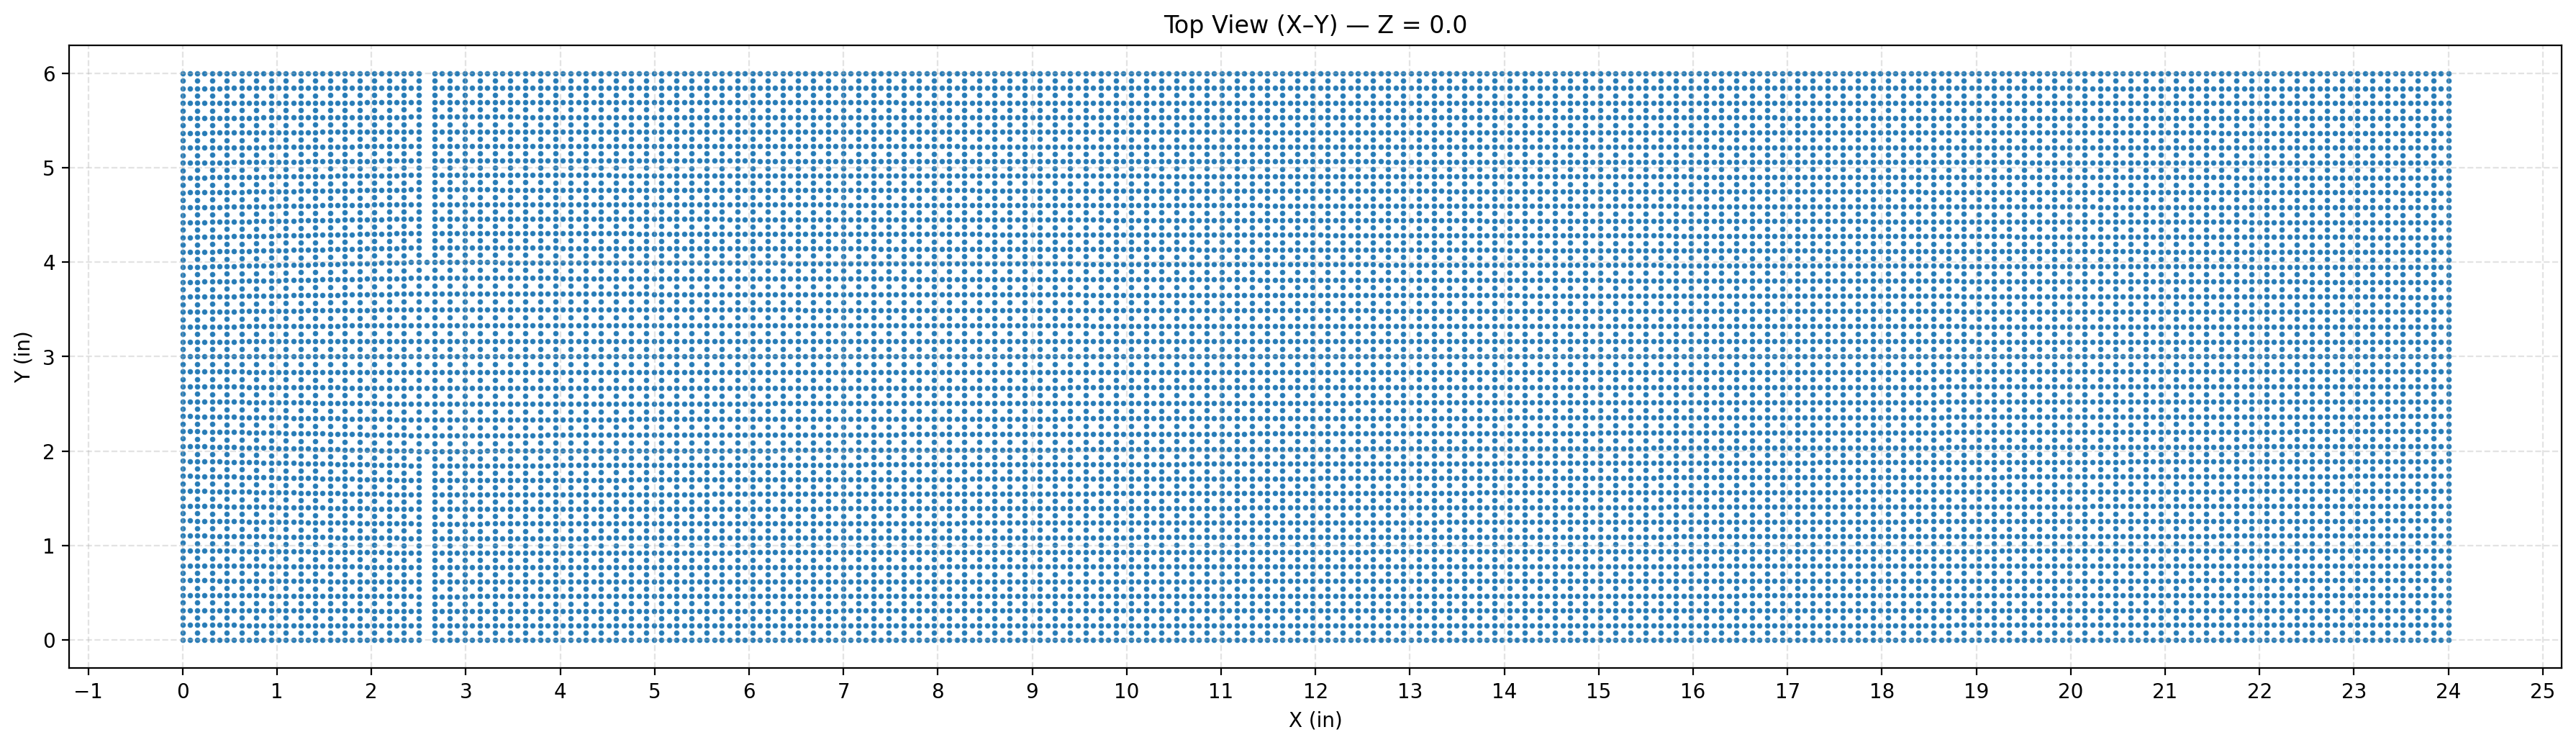

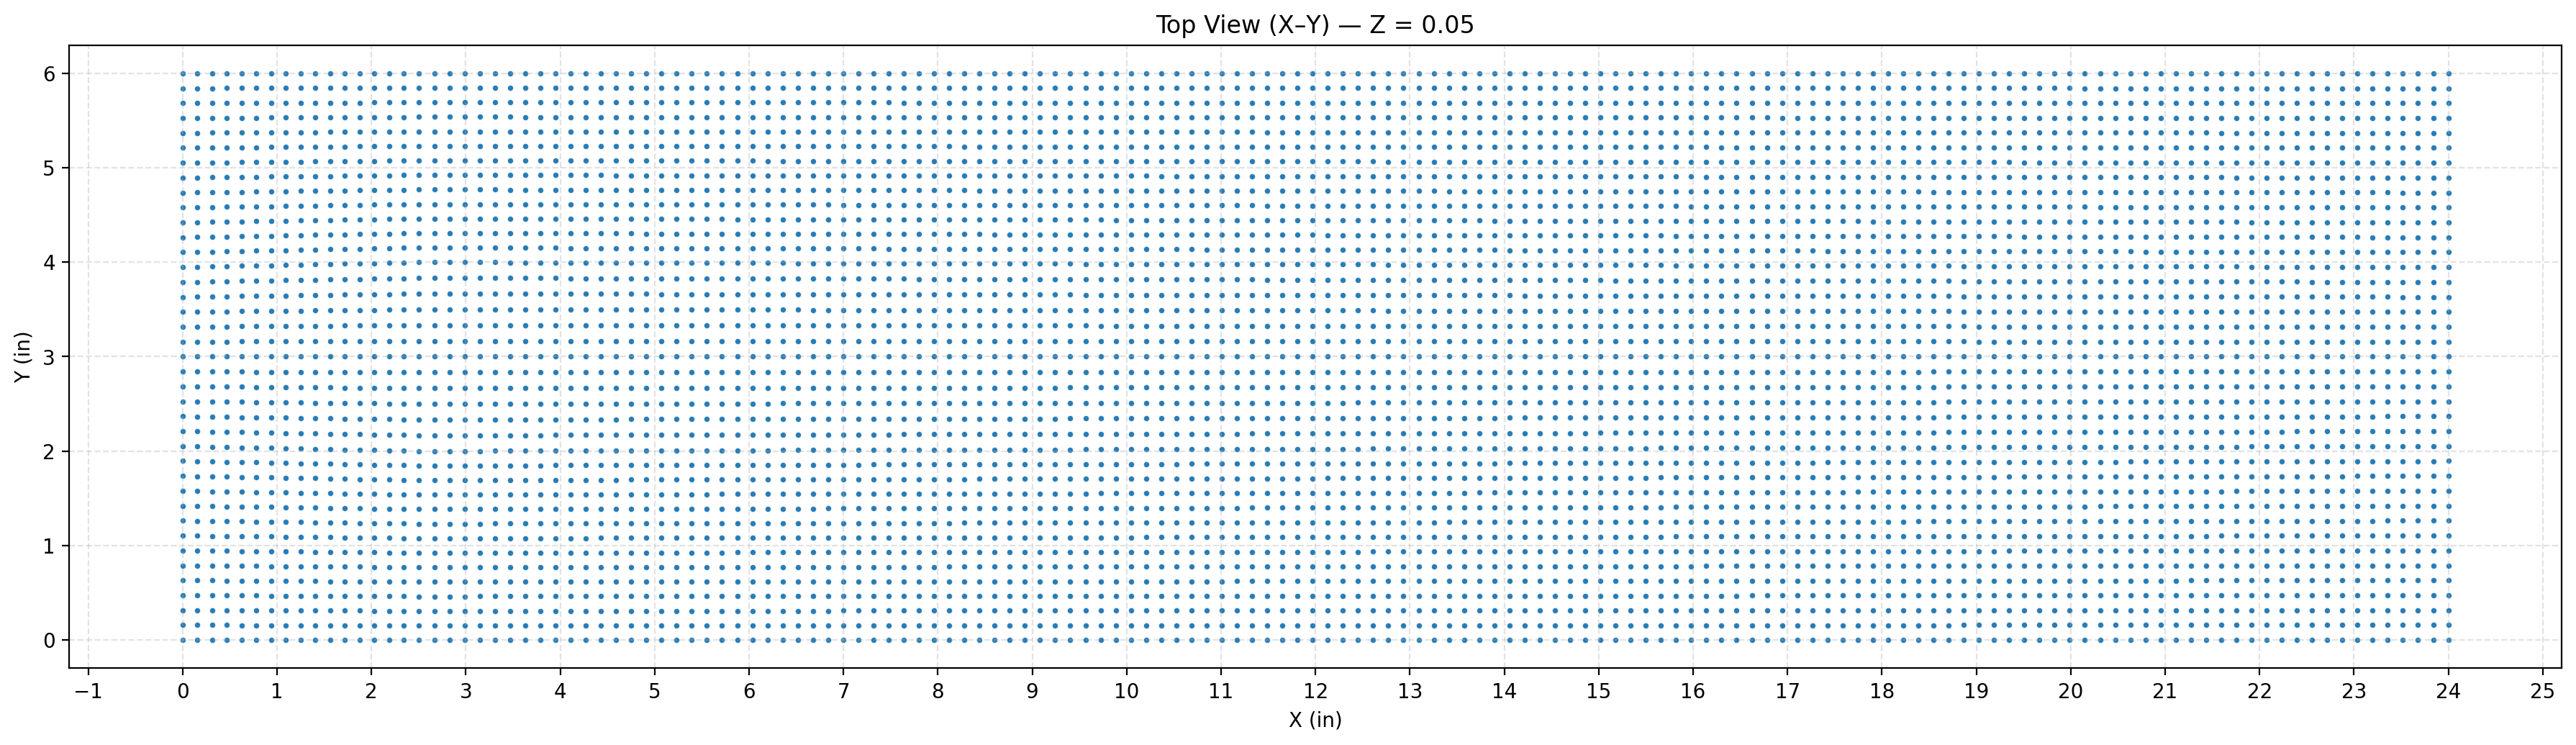

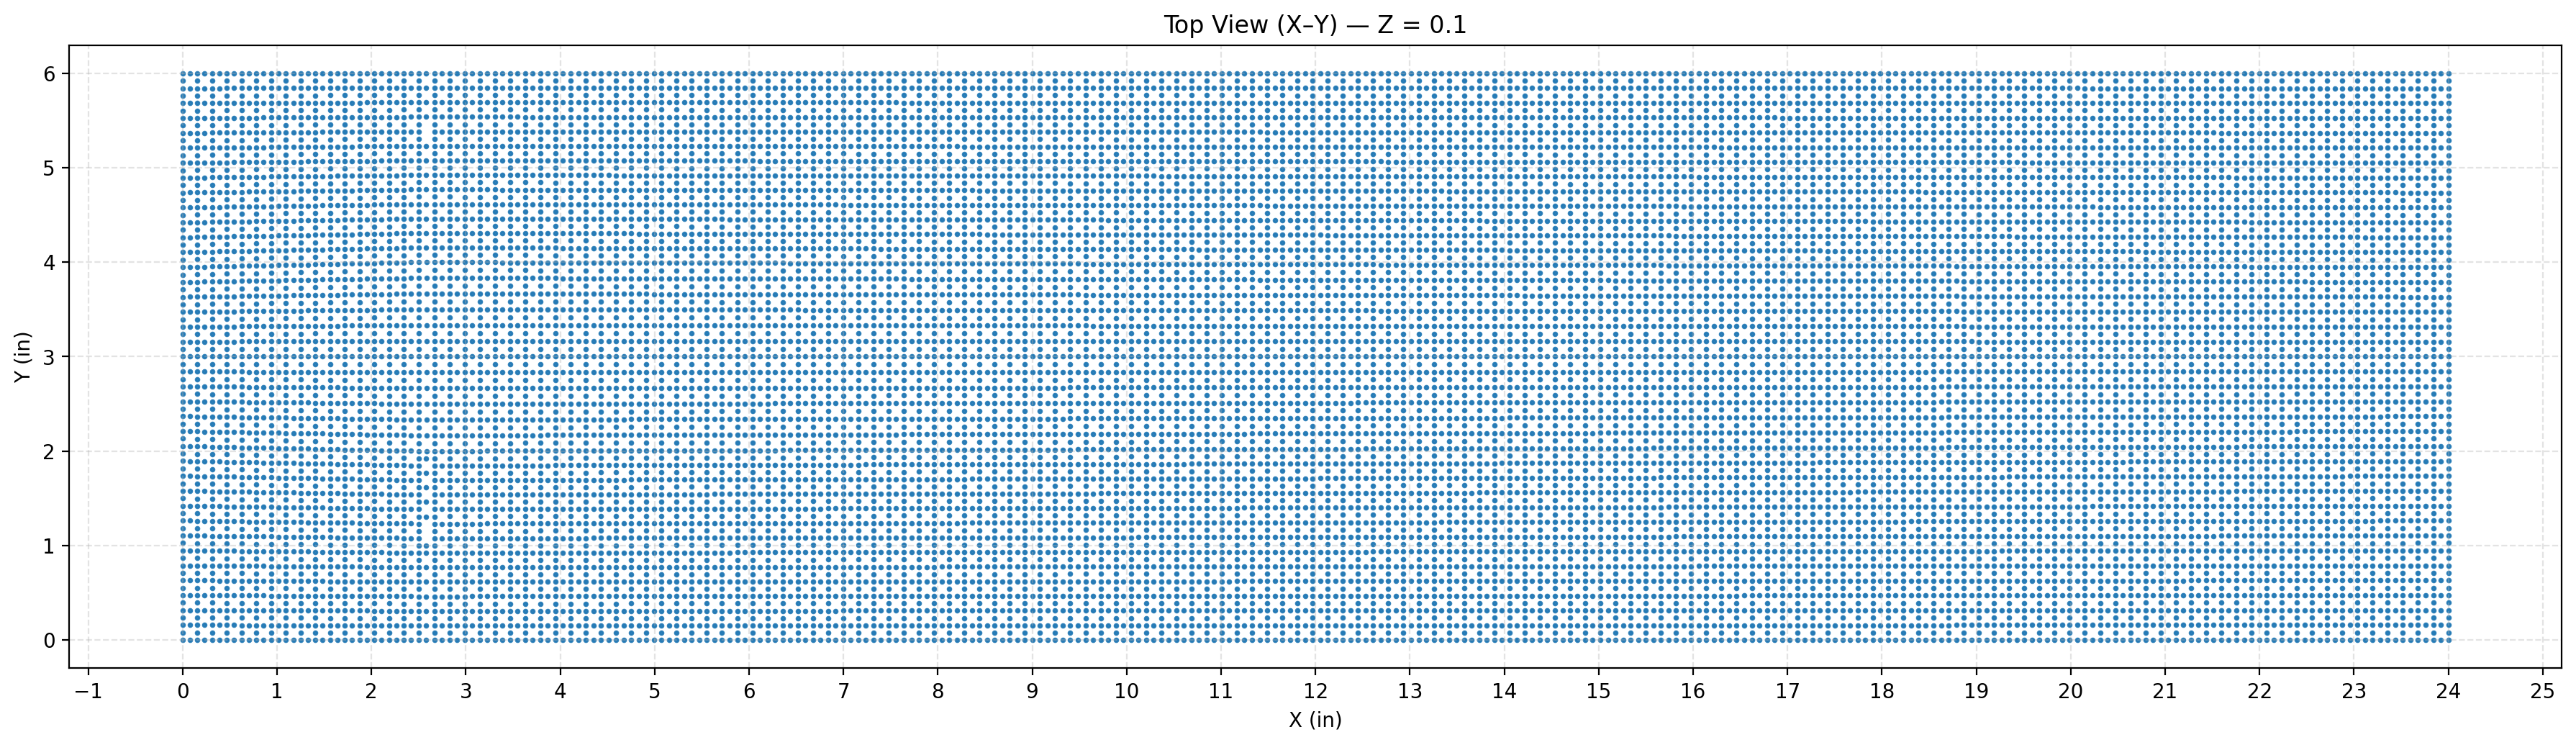

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

CSV_PATH = "assets/Node_Cords_40k.csv"

# ---- Load ----
df = pd.read_csv(CSV_PATH).rename(columns={
    "Node Number": "node",
    "X Location (in)": "x",
    "Y Location (in)": "y",
    "Z Location (in)": "z",
})

# Stabilize floats
df["x"] = df["x"].astype(float).round(6)
df["y"] = df["y"].astype(float).round(6)
df["z"] = df["z"].astype(float)
df["z_r"] = df["z"].round(4)

z_layers = sorted(df["z_r"].unique())
print("Detected Z layers:", z_layers)

# Tick spacing (adjust for readability)
x_tick = 1.0
y_tick = 1.0

# ---- Make one figure per Z layer ----
for z in z_layers:
    layer = df[df["z_r"] == z]

    plt.figure(figsize=(18, 10), dpi=200)  # big, readable
    plt.scatter(layer["x"], layer["y"], s=3, alpha=0.9)

    plt.title(f"Top View (X–Y) — Z = {z}")
    plt.xlabel("X (in)")
    plt.ylabel("Y (in)")
    plt.gca().set_aspect("equal", adjustable="box")

    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(x_tick))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick))
    ax.grid(True, linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.show()


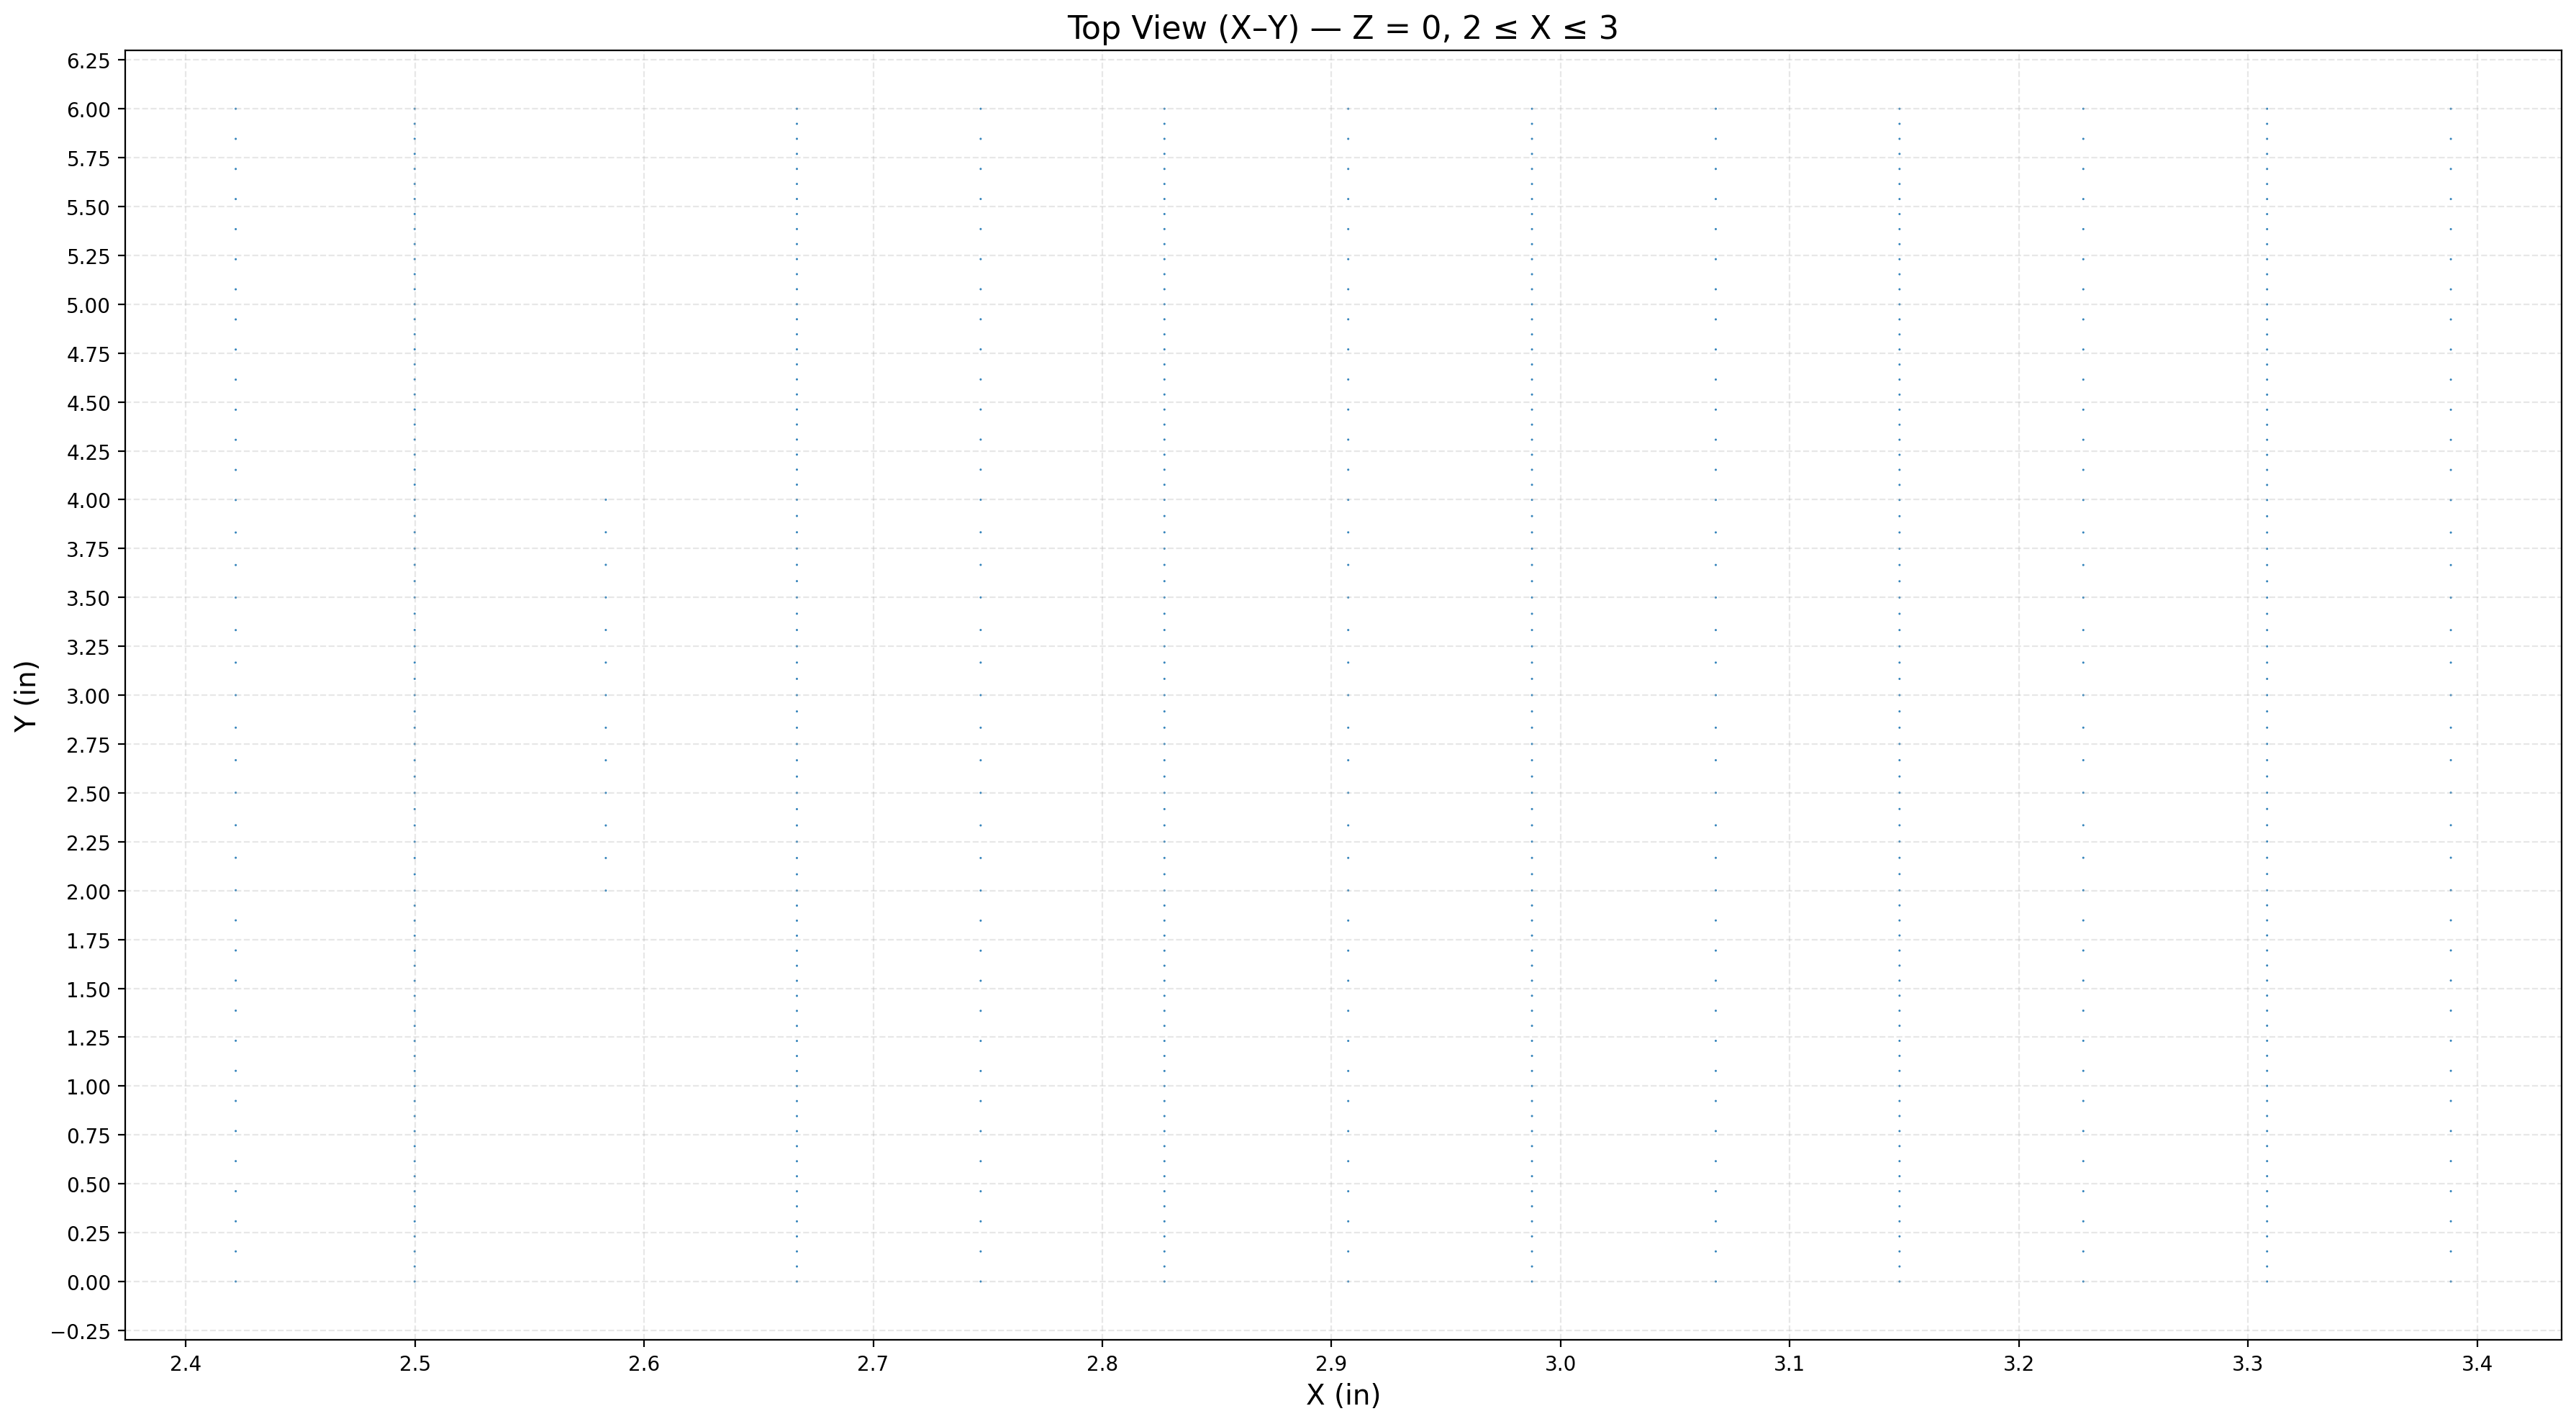

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

CSV_PATH = "assets/Node_Cords_40k.csv"

df = pd.read_csv(CSV_PATH).rename(columns={
    "Node Number": "node",
    "X Location (in)": "x",
    "Y Location (in)": "y",
    "Z Location (in)": "z",
})

df["x"] = df["x"].astype(float).round(6)
df["y"] = df["y"].astype(float).round(6)
df["z"] = df["z"].astype(float).round(4)

layer = df[(df["z"] == 0.0) & (df["x"] >= 2.4) & (df["x"] <= 3.4)]

plt.figure(figsize=(18, 10), dpi=200)
plt.scatter(layer["x"], layer["y"], s=1.2, alpha=0.9, edgecolors="none")

plt.title("Top View (X–Y) — Z = 0, 2 ≤ X ≤ 3", fontsize=16)
plt.xlabel("X (in)", fontsize=14)
plt.ylabel("Y (in)", fontsize=14)

ax = plt.gca()

# IMPORTANT: remove equal aspect so X isn't squished
ax.set_aspect("auto")

# Nice ticks for inspection
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.25))
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
